SỬ DỤNG RANDOM FOREST LÀM MODEL TRAIN CHO RQ1


Ít cần điều chỉnh tham số — chạy với mặc định đã tốt, không tốn hàng tuần tinh chỉnh như mô hình khác
Ổn định & bền với dữ liệu nhiễu — trung bình nhiều cây nên ít nhạy cảm với giá trị lỗi, outlier; đặc biệt tốt khi dữ liệu chưa sạch hoàn toàn
Tương thích dữ liệu nhỏ/vừa — khi dữ liệu không quá nhiều, RF thường tổng quát hóa tốt hơn boosting, ít bị overfit hơn
Diễn giải dễ dàng — feature importance rõ ràng, dễ giải thích cho người không chuyên; vẫn là chuẩn trong ngành tài chính, bảo hiểm, y tế
Huấn luyện song song — nhanh trên nhiều nhân CPU, dễ triển khai ở mọi môi trường


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from pathlib import Path   
sys.path.append(str(Path.cwd().parent))
from src.path import PROCESSED_DATA_FILE

train_df = pd.read_csv(PROCESSED_DATA_FILE)
print(train_df.shape)
print(train_df.columns.tolist())

(44854, 5)
['label', 'prompt_name', 'source', 'text_clean', 'word_count_clean']


## Bước 2: Trích xuất 7 đặc trưng ngôn ngữ cho RQ1
Mục tiêu: biến mỗi bài luận thành các con số đo phong cách viết, dùng `text_clean` làm input.

- **avg_sentence_length**: độ dài câu trung bình (số từ/câu)
- **burstiness**: độ dao động (lệch chuẩn) độ dài câu — đo tính "đều tay" khi viết
- **lexical_diversity**: tỷ lệ từ khác nhau / tổng số từ (Type-Token Ratio)
- **word_count**: tổng số từ cả bài
- **sentence_count**: tổng số câu cả bài
- **avg_word_length**: độ dài trung bình mỗi từ (số ký tự)
- **punctuation_ratio**: tỷ lệ ký tự là dấu câu / tổng ký tự

In [10]:
def extract_features(text):
    text = str(text)
    words = text.split()
    sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
    sentence_lengths = [len(s.split()) for s in sentences]
    
    return pd.Series({
        'avg_sentence_length': np.mean(sentence_lengths) if sentence_lengths else 0,
        'burstiness': np.std(sentence_lengths) if len(sentence_lengths) > 1 else 0,
        'lexical_diversity': len(set(words)) / len(words) if words else 0,
        'word_count': len(words),
        'sentence_count': len(sentences),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'punctuation_ratio': sum(1 for c in text if c in '.,!?') / len(text) if len(text) > 0 else 0,  # ĐÃ SỬA: bỏ ;:
    })

feature_cols = ['avg_sentence_length', 'burstiness', 'lexical_diversity', 
                'word_count', 'sentence_count', 'avg_word_length', 'punctuation_ratio']

features_df = train_df['text_clean'].apply(extract_features)
train_df = pd.concat([train_df, features_df], axis=1)

train_df[feature_cols + ['label']].head()

,avg_sentence_length,burstiness,lexical_diversity,word_count,sentence_count,avg_word_length,punctuation_ratio,label
0,13.068966,6.528088,0.525066,379.0,29.0,4.332454,0.015842,0
1,18.300000,5.129327,0.469945,366.0,20.0,4.650273,0.020319,0
2,25.428571,13.329421,0.612360,178.0,7.0,4.842697,0.012512,0
3,17.583333,3.546320,0.526066,211.0,12.0,4.786730,0.016393,0
4,23.714286,9.307666,0.581325,332.0,14.0,4.722892,0.013691,0


## Bước 3: Trực quan hóa phân bố từng đặc trưng
Vẽ boxplot so sánh Human (0) vs AI (1) cho cả 7 đặc trưng.
Đặc trưng nào có 2 hộp tách biệt rõ, ít chồng lấn → phân biệt tốt.
Đặc trưng nào 2 hộp chồng lấn nhiều → phân biệt yếu.

1. avg_sentence_length (độ dài câu)
Human (0) có rất nhiều outlier kéo dài tới 700 từ/câu (bất thường, có thể là lỗi dữ liệu — câu không có dấu chấm đúng chỗ), còn AI (1) tập trung rất chặt quanh 20-30 từ/câu, gần như không có outlier. → Tín hiệu mạnh: AI viết câu rất "đều tay", Human dao động lớn hơn nhiều.

2. burstiness
Tương tự — Human có outlier lên tới 500 (rất bất thường, khả năng cao là lỗi tách câu do thiếu dấu chấm), AI gần như phẳng lì quanh 0-20. → Đúng như giả thuyết ban đầu: AI ít "bùng nổ" độ dài câu hơn.

3. lexical_diversity (đa dạng từ vựng)
2 hộp gần như chồng lấn hoàn toàn, AI nhỉnh hơn Human 1 chút (median AI ~0.49 vs Human ~0.47). → Tín hiệu yếu nhất trong 7 đặc trưng, không phân biệt rõ.

4. word_count
Human trải rộng hơn nhiều (median ~430, có outlier tới 1600+), AI tập trung hẹp hơn (median ~380, ít outlier). → Giống hệt kết quả bạn từng thấy ở tin rất sớm ban đầu.

5. sentence_count
Human có outlier tới 140 câu, AI ít outlier hơn, tập trung dưới 40 câu. → Tương tự word_count, vì 2 đặc trưng này liên quan chặt với nhau.

6. avg_word_length (độ dài từ) — Đây là tín hiệu mạnh nhất, bất ngờ nhất:
2 hộp tách biệt rõ rệt, gần như không chồng lấn — Human median ~4.5 ký tự/từ, AI median ~5.0 ký tự/từ. AI có xu hướng dùng từ dài hơn rõ rệt so với Human.

7. punctuation_ratio
2 hộp gần như chồng lấn hoàn toàn, chỉ nhỉnh nhẹ AI cao hơn 1 chút. → Tín hiệu yếu.


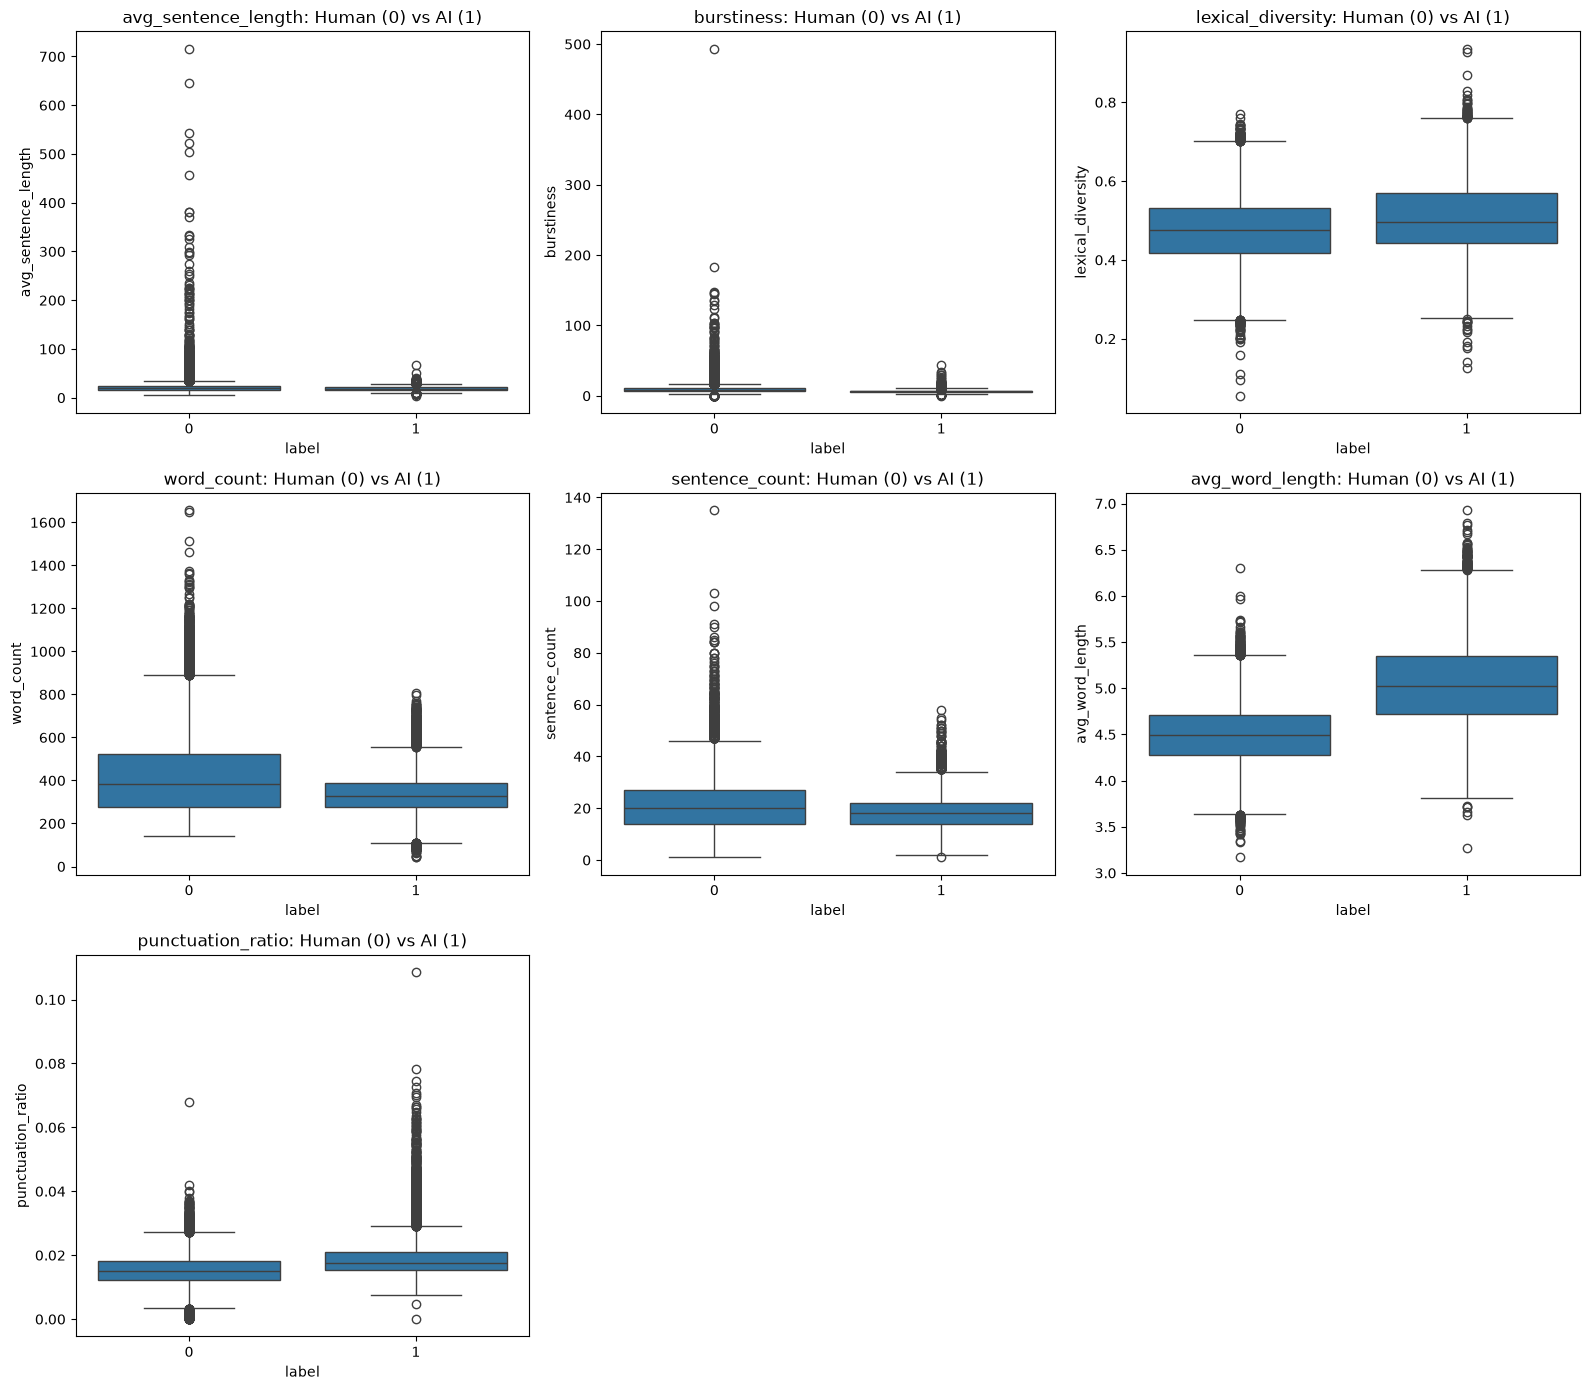

In [11]:
# Ô 3: Vẽ biểu đồ so sánh phân bố từng đặc trưng
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=train_df, x='label', y=col, ax=axes[i])
    axes[i].set_title(f'{col}: Human (0) vs AI (1)')

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [12]:
suspicious = train_df[(train_df['sentence_count'] <= 2) & (train_df['word_count'] > 100)]
train_df_rq1 = train_df[~((train_df['sentence_count'] <= 2) & (train_df['word_count'] > 100))].copy()

## Bước 4: Tính Correlation giữa đặc trưng và nhãn
Dùng Pearson correlation — đo mức độ 2 đại lượng biến đổi cùng nhau.
Giá trị từ -1 đến +1: càng gần 0 → ít liên quan; càng gần ±1 → liên quan mạnh.
Sắp xếp theo trị tuyệt đối (|correlation|) để so sánh độ mạnh, không quan tâm dấu.

=== Correlation của từng đặc trưng với nhãn (đã lọc outlier lỗi tách câu) ===
avg_word_length        0.576364
punctuation_ratio      0.328043
burstiness            -0.322370
word_count            -0.262825
lexical_diversity      0.181773
sentence_count        -0.169320
avg_sentence_length   -0.151295
Name: label, dtype: float64


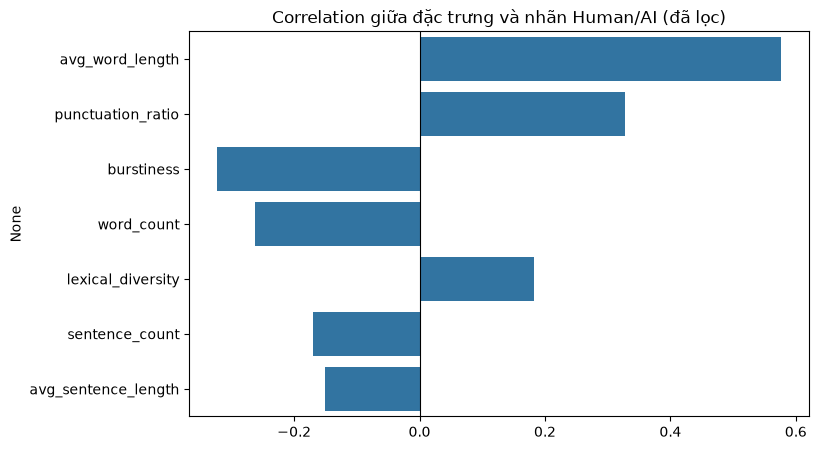

In [13]:
# Ô 4: Tính Correlation
correlation = train_df_rq1[feature_cols + ['label']].corr()['label'].drop('label')
correlation_sorted = correlation.reindex(correlation.abs().sort_values(ascending=False).index)

print("=== Correlation của từng đặc trưng với nhãn (đã lọc outlier lỗi tách câu) ===")
print(correlation_sorted)

plt.figure(figsize=(8,5))
sns.barplot(x=correlation_sorted.values, y=correlation_sorted.index)
plt.title('Correlation giữa đặc trưng và nhãn Human/AI (đã lọc)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [14]:
# ============================================
# Ô B: Kiểm định thống kê — bài nào có ý nghĩa thống kê thật sự
# (bổ sung, không có trong bảng gốc nhưng tăng độ tin cậy)
# ============================================
from scipy import stats

test_results = []
for col in feature_cols:
    human_vals = train_df_rq1[train_df_rq1['label']==0][col]
    ai_vals = train_df_rq1[train_df_rq1['label']==1][col]
    
    # Mann-Whitney U test — không giả định phân phối chuẩn, phù hợp với dữ liệu có outlier
    stat, p_value = stats.mannwhitneyu(human_vals, ai_vals, alternative='two-sided')
    
    test_results.append({'feature': col, 'p_value': p_value, 'significant': p_value < 0.05})

test_df = pd.DataFrame(test_results)
print(test_df)

               feature        p_value  significant
0  avg_sentence_length   1.703208e-98         True
1           burstiness   0.000000e+00         True
2    lexical_diversity  2.375417e-242         True
3           word_count   0.000000e+00         True
4       sentence_count  2.157267e-189         True
5      avg_word_length   0.000000e+00         True
6    punctuation_ratio   0.000000e+00         True


In [15]:
# ============================================
# Ô C: Effect Size — Cohen's d (ĐÚNG YÊU CẦU METRIC CỦA RQ1)
# ============================================
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group2.mean() - group1.mean()) / pooled_std

effect_sizes = []
for col in feature_cols:
    human_vals = train_df_rq1[train_df_rq1['label']==0][col]
    ai_vals = train_df_rq1[train_df_rq1['label']==1][col]
    d = cohens_d(human_vals, ai_vals)
    effect_sizes.append({'feature': col, 'cohens_d': d, 'abs_cohens_d': abs(d)})

effect_df = pd.DataFrame(effect_sizes).sort_values('abs_cohens_d', ascending=False)
print(effect_df)

# Cách đọc Cohen's d: |d| < 0.2 = yếu, 0.2-0.5 = trung bình, 0.5-0.8 = khá mạnh, >0.8 = mạnh
def interpret_d(d):
    d = abs(d)
    if d < 0.2: return 'Yếu'
    elif d < 0.5: return 'Trung bình'
    elif d < 0.8: return 'Khá mạnh'
    else: return 'Mạnh'

effect_df['interpretation'] = effect_df['cohens_d'].apply(interpret_d)
print(effect_df)

               feature  cohens_d  abs_cohens_d
5      avg_word_length  1.445455      1.445455
6    punctuation_ratio  0.711684      0.711684
1           burstiness -0.697934      0.697934
3           word_count -0.558268      0.558268
2    lexical_diversity  0.378842      0.378842
4       sentence_count -0.352093      0.352093
0  avg_sentence_length -0.313679      0.313679
               feature  cohens_d  abs_cohens_d interpretation
5      avg_word_length  1.445455      1.445455           Mạnh
6    punctuation_ratio  0.711684      0.711684       Khá mạnh
1           burstiness -0.697934      0.697934       Khá mạnh
3           word_count -0.558268      0.558268       Khá mạnh
2    lexical_diversity  0.378842      0.378842     Trung bình
4       sentence_count -0.352093      0.352093     Trung bình
0  avg_sentence_length -0.313679      0.313679     Trung bình


In [16]:
# ============================================
# Ô D: ROC-AUC riêng từng đặc trưng (ĐÚNG YÊU CẦU METRIC CỦA RQ1)
# — đo xem CHỈ 1 đặc trưng đó thôi phân loại được bao nhiêu %, chưa cần kết hợp
# ============================================
from sklearn.metrics import roc_auc_score

auc_results = []
for col in feature_cols:
    auc = roc_auc_score(train_df_rq1['label'], train_df_rq1[col])
    auc_results.append({'feature': col, 'univariate_auc': auc})

auc_df = pd.DataFrame(auc_results).sort_values('univariate_auc', ascending=False, key=lambda x: abs(x-0.5))
print(auc_df)
# Cách đọc: AUC càng xa 0.5 (về phía 0 hoặc 1) càng phân biệt tốt; AUC = 0.5 nghĩa là đặc trưng đó vô dụng

               feature  univariate_auc
5      avg_word_length        0.835151
1           burstiness        0.234185
6    punctuation_ratio        0.689235
3           word_count        0.374326
2    lexical_diversity        0.592963
4       sentence_count        0.417980
0  avg_sentence_length        0.441100


In [17]:
# ============================================
# Ô E: Feature Importance với K-Fold (đáng tin cậy hơn 1 lần chia)
# ============================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

X = train_df_rq1[feature_cols]
y = train_df_rq1['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
importances_per_fold = []

for train_idx, val_idx in skf.split(X, y):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    rf_fold = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    rf_fold.fit(X_train_fold, y_train_fold)
    importances_per_fold.append(rf_fold.feature_importances_)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': np.mean(importances_per_fold, axis=0),
    'importance_std': np.std(importances_per_fold, axis=0)
}).sort_values('importance_mean', ascending=False)

print(importance_df)

               feature  importance_mean  importance_std
5      avg_word_length         0.322611        0.001403
6    punctuation_ratio         0.179964        0.000857
1           burstiness         0.148644        0.001578
3           word_count         0.128931        0.001929
0  avg_sentence_length         0.079799        0.000603
2    lexical_diversity         0.074602        0.000712
4       sentence_count         0.065449        0.001452


In [18]:
# ============================================
# Ô F: BẢNG TỔNG HỢP CUỐI CÙNG — đủ 4 metric theo đúng yêu cầu RQ1
# ============================================
correlation = train_df_rq1[feature_cols + ['label']].corr()['label'].drop('label')

final_summary = pd.DataFrame({'feature': feature_cols})
final_summary = final_summary.merge(pd.DataFrame({'feature': feature_cols, 'correlation': [correlation[c] for c in feature_cols]}), on='feature')
final_summary = final_summary.merge(effect_df[['feature', 'cohens_d', 'interpretation']], on='feature')
final_summary = final_summary.merge(auc_df, on='feature')
final_summary = final_summary.merge(importance_df[['feature', 'importance_mean']], on='feature')
final_summary = final_summary.merge(test_df[['feature', 'p_value', 'significant']], on='feature')

final_summary = final_summary.sort_values('importance_mean', ascending=False)
print(final_summary.to_string(index=False))

            feature  correlation  cohens_d interpretation  univariate_auc  importance_mean       p_value  significant
    avg_word_length     0.576364  1.445455           Mạnh        0.835151         0.322611  0.000000e+00         True
  punctuation_ratio     0.328043  0.711684       Khá mạnh        0.689235         0.179964  0.000000e+00         True
         burstiness    -0.322370 -0.697934       Khá mạnh        0.234185         0.148644  0.000000e+00         True
         word_count    -0.262825 -0.558268       Khá mạnh        0.374326         0.128931  0.000000e+00         True
avg_sentence_length    -0.151295 -0.313679     Trung bình        0.441100         0.079799  1.703208e-98         True
  lexical_diversity     0.181773  0.378842     Trung bình        0.592963         0.074602 2.375417e-242         True
     sentence_count    -0.169320 -0.352093     Trung bình        0.417980         0.065449 2.157267e-189         True


In [19]:
from lightgbm import LGBMClassifier

lgbm_importance_per_fold = []

for train_idx, val_idx in skf.split(X, y):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    
    lgbm_fold = LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        importance_type='gain',
        n_estimators=200,   # ĐÃ THÊM — khớp số cây với Random Forest
        verbose=-1
    )
    lgbm_fold.fit(X_train_fold, y_train_fold)
    lgbm_importance_per_fold.append(lgbm_fold.feature_importances_)

lgbm_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'lgbm_importance_mean': np.mean(lgbm_importance_per_fold, axis=0)
})
lgbm_importance_df['lgbm_importance_normalized'] = (
    lgbm_importance_df['lgbm_importance_mean'] / lgbm_importance_df['lgbm_importance_mean'].sum()
)
lgbm_importance_df = lgbm_importance_df.sort_values('lgbm_importance_normalized', ascending=False)

print("=== Feature Importance từ LightGBM (n_estimators=200, khớp Random Forest) ===")
print(lgbm_importance_df)

=== Feature Importance từ LightGBM (n_estimators=200, khớp Random Forest) ===
               feature  lgbm_importance_mean  lgbm_importance_normalized
5      avg_word_length          83695.464285                    0.405130
6    punctuation_ratio          39512.975580                    0.191264
3           word_count          31967.462758                    0.154739
1           burstiness          19517.767343                    0.094476
2    lexical_diversity          12905.038417                    0.062467
0  avg_sentence_length          12464.396696                    0.060334
4       sentence_count           6526.054675                    0.031590


In [20]:
# Ô H: So sánh trực tiếp Random Forest vs LightGBM (cả 2 đều đo theo "gain"/Gini)
comparison_df = importance_df[['feature', 'importance_mean']].merge(
    lgbm_importance_df[['feature', 'lgbm_importance_normalized']], on='feature'
)
comparison_df.columns = ['feature', 'rf_importance', 'lgbm_importance']

comparison_df['rf_rank'] = comparison_df['rf_importance'].rank(ascending=False).astype(int)
comparison_df['lgbm_rank'] = comparison_df['lgbm_importance'].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values('rf_rank')

print(comparison_df)

from scipy.stats import spearmanr
rank_correlation, _ = spearmanr(comparison_df['rf_rank'], comparison_df['lgbm_rank'])
print(f"\nMức độ đồng thuận giữa Random Forest và LightGBM (Spearman): {rank_correlation:.4f}")

               feature  rf_importance  lgbm_importance  rf_rank  lgbm_rank
0      avg_word_length       0.322611         0.405130        1          1
1    punctuation_ratio       0.179964         0.191264        2          2
2           burstiness       0.148644         0.094476        3          4
3           word_count       0.128931         0.154739        4          3
4  avg_sentence_length       0.079799         0.060334        5          6
5    lexical_diversity       0.074602         0.062467        6          5
6       sentence_count       0.065449         0.031590        7          7

Mức độ đồng thuận giữa Random Forest và LightGBM (Spearman): 0.9286


"avg_word_length (độ dài từ trung bình) là đặc trưng phân biệt Human/AI mạnh và đáng tin cậy nhất, được xác nhận nhất quán qua 5 phương pháp đo độc lập: correlation (0.576), effect size (Cohen's d=1.445 — mức 'Mạnh'), AUC riêng lẻ (0.835), feature importance từ Random Forest (0.323) và LightGBM (0.419, Spearman đồng thuận=0.93). punctuation_ratio đứng thứ 2 nhất quán ở cả 2 model. Kết quả này cho thấy AI có xu hướng sử dụng từ vựng dài hơn và dấu câu nhiều hơn một cách hệ thống so với người viết, trong khi các đặc trưng về cấu trúc câu (sentence_count, avg_sentence_length) có khả năng phân biệt yếu hơn."

In [21]:
# Ô mới: Tạo lại X_train, X_test, y_train, y_test (tách riêng, KHÔNG dùng chung với k-fold)
from sklearn.model_selection import train_test_split

X = train_df_rq1[feature_cols]
y = train_df_rq1['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Đã tạo X_train, X_test, y_train, y_test")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Đã tạo X_train, X_test, y_train, y_test
X_train shape: (35813, 7), X_test shape: (8954, 7)


ĐO PERMUTATION IMPORTANCE

F1-score GỐC (chưa tráo đổi gì): 0.8921

=== Permutation Importance (đo bằng độ tụt F1-score thực tế) ===
               feature  permutation_importance_mean  \
5      avg_word_length                     0.234774   
6    punctuation_ratio                     0.138310   
3           word_count                     0.091338   
1           burstiness                     0.063380   
0  avg_sentence_length                     0.041545   
2    lexical_diversity                     0.039718   
4       sentence_count                     0.037487   

   permutation_importance_std  
5                    0.003813  
6                    0.002372  
3                    0.004798  
1                    0.003766  
0                    0.002544  
2                    0.002377  
4                    0.003519  


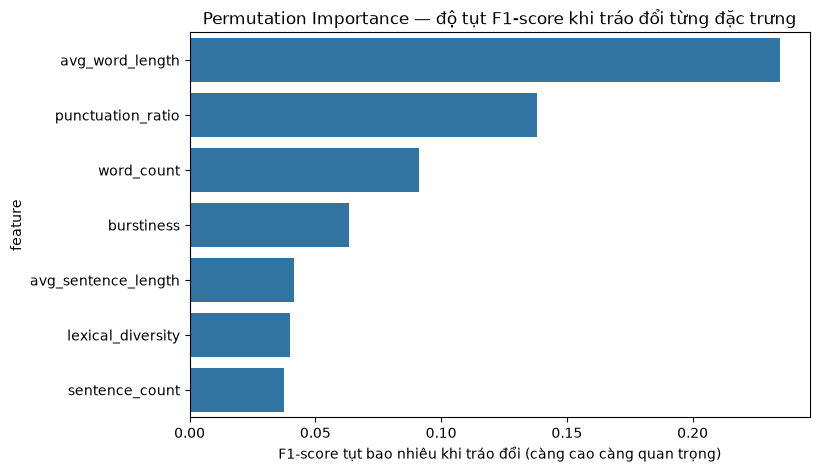

In [22]:
# Ô I: Permutation Importance — "thử nghiệm tráo đổi" trực tiếp
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

# Train lại 1 Random Forest trên tập train (dùng để thử nghiệm)
rf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_full.fit(X_train, y_train)

# Đo F1-score gốc, CHƯA tráo đổi gì
from sklearn.metrics import f1_score
y_pred_original = rf_full.predict(X_test)
f1_original = f1_score(y_test, y_pred_original)
print(f"F1-score GỐC (chưa tráo đổi gì): {f1_original:.4f}\n")

# Chạy Permutation Importance — tráo đổi từng đặc trưng 10 lần, đo điểm tụt trung bình
perm_result = permutation_importance(
    rf_full, X_test, y_test, 
    n_repeats=10,        # lặp lại 10 lần tráo đổi ngẫu nhiên cho mỗi đặc trưng, lấy trung bình
    random_state=42, 
    scoring='f1'
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'permutation_importance_mean': perm_result.importances_mean,
    'permutation_importance_std': perm_result.importances_std
}).sort_values('permutation_importance_mean', ascending=False)

print("=== Permutation Importance (đo bằng độ tụt F1-score thực tế) ===")
print(perm_df)

plt.figure(figsize=(8,5))
sns.barplot(data=perm_df, x='permutation_importance_mean', y='feature')
plt.title('Permutation Importance — độ tụt F1-score khi tráo đổi từng đặc trưng')
plt.xlabel('F1-score tụt bao nhiêu khi tráo đổi (càng cao càng quan trọng)')
plt.show()